In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_excel("data/data.xlsx")
df.head()

,N,Approval Date,Tier,FICO,Term,Amount,Loan Type,Previous Rate,Competition rate,Cost of Funds,Partner,Rate,Outcome
0,1,2005-04-17,2,702,48,26500.00,R,0.0399,0.0499,0.011,2,0.0659,0
1,2,2005-04-17,2,719,72,34999.99,N,0.0000,0.0479,0.011,2,0.0599,0
2,3,2005-04-17,1,802,60,28000.00,N,0.0000,0.0399,0.011,3,0.0355,0
3,4,2005-04-17,1,723,60,20750.69,R,0.0675,0.0499,0.011,1,0.0489,1
4,5,2005-04-17,3,690,72,19999.99,U,0.0000,0.0529,0.011,1,0.0679,0


([<matplotlib.axis.XTick at 0x7f7c9635cc10>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3'), Text(4, 0, '4')])

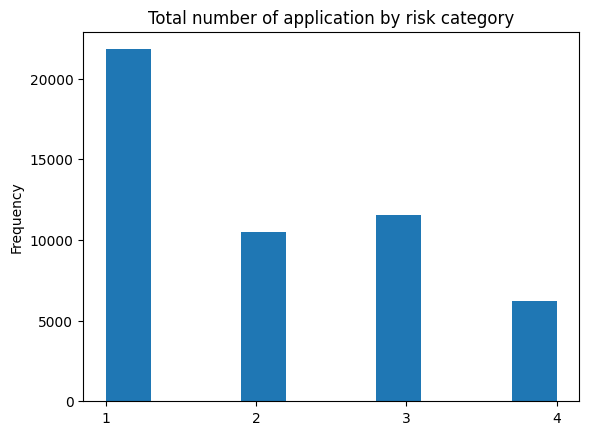

In [4]:
# the loans are already divided into 4 risk categories 1 -> less risk, 4 most risky
df["Tier"].plot.hist()
plt.title("Total number of application by risk category")
plt.xticks([1,2,3,4])

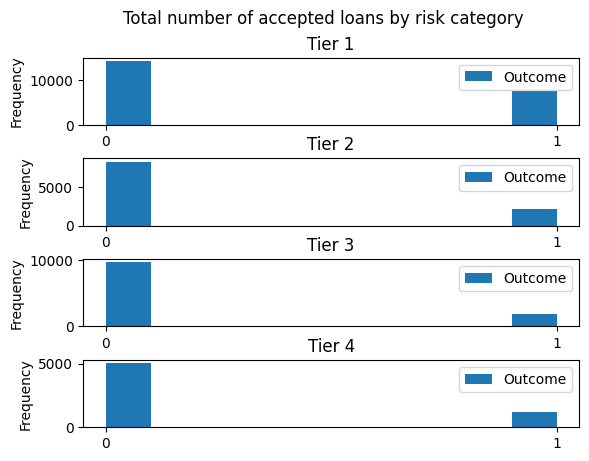

In [5]:
axes = df[["Tier", "Outcome"]].plot.hist("Tier")
for i, ax in enumerate(axes): 
    ax.set_xticks([0,1])
    ax.set_title(f"Tier {i+1}")
plt.suptitle("Total number of accepted loans by risk category")
plt.subplots_adjust(hspace=0.5)


Text(0.5, 1.0, 'Outome vs Offered rate')

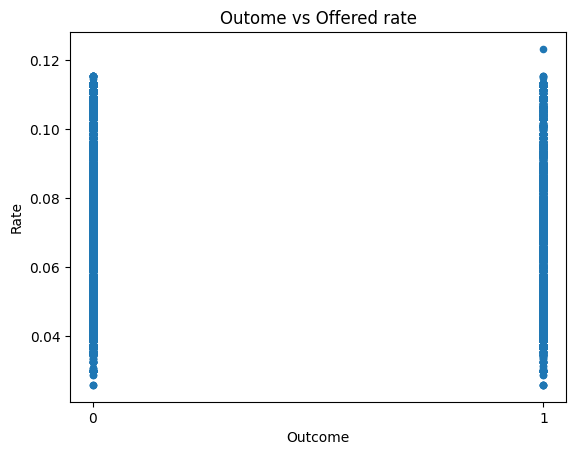

In [6]:
df[["Rate", "Outcome"]].plot.scatter("Outcome", "Rate")
plt.xticks([0,1])
plt.title("Outome vs Offered rate")

In [28]:
l = df["Rate"].quantile(0.025)
u = df["Rate"].quantile(0.975)
df_ = df[(df["Rate"]<u) & (df["Rate"]>l)]
print("The correlation of Rate and Outcome in the full df is: ", df_["Rate"].corr(df_["Outcome"]))
for i in range(4):
    df_ = df[df["Tier"] == i+1]
    l = df_["Rate"].quantile(0.025)
    u = df_["Rate"].quantile(0.975)
    df_ = df_[(df_["Rate"]<u) & (df_["Rate"]>l)]
    print(f"The correlation of Rate and Outcome for loans in Tier {i+1} is: ", df_["Rate"].corr(df_["Outcome"]))

#No big difference if we remove the outliers

The correlation of Rate and Outcome in the full df is:  -0.1426569970910861
The correlation of Rate and Outcome for loans in Tier 1 is:  0.15582181711680315
The correlation of Rate and Outcome for loans in Tier 2 is:  0.022602237390351925
The correlation of Rate and Outcome for loans in Tier 3 is:  -0.08159653713380992
The correlation of Rate and Outcome for loans in Tier 4 is:  -0.1644807053560014


Text(0.5, 0.98, 'Outcome vs Offered Rate by Category')

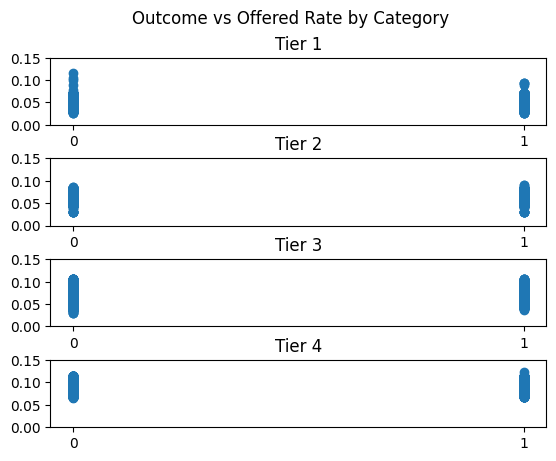

In [ ]:
fig, axes = plt.subplots(4,1)
for i, ax in enumerate(axes):
    df_ = df[df["Tier"] == 1+i]
    ax.scatter(df_["Outcome"],df_["Rate"])
    ax.set_xticks([0,1])
    ax.set_yticks([0, 0.05, 0.1, 0.15])
    ax.set_title(f"Tier {i+1}")

plt.subplots_adjust(hspace=0.5)
plt.suptitle("Outcome vs Offered Rate by Category")
    

Text(0.5, 0.98, 'Accepted and rejected rates histogram by categories')

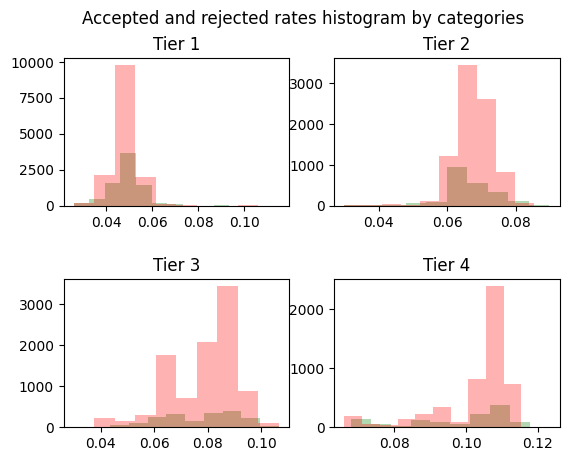

In [8]:
fig, axes = plt.subplots(2,2)
for i, ax in enumerate(axes.flatten()):
    df_ = df[df["Tier"] == 1+i]
    ax.hist(df_[df_["Outcome"]==1]["Rate"], alpha=0.3, color="green")
    ax.hist(df_[df_["Outcome"]==0]["Rate"], alpha=0.3, color="red")
    ax.set_title(f"Tier {i+1}")

plt.subplots_adjust(hspace=0.5)
plt.suptitle("Accepted and rejected rates histogram by categories")
    

/tmp/ipykernel_25346/1662139753.py:6: RuntimeWarning: invalid value encountered in divide
  ax.plot([0.01*i for i in range(14)], accepted_per_bucket/total_per_bucket)
/tmp/ipykernel_25346/1662139753.py:6: RuntimeWarning: invalid value encountered in divide
  ax.plot([0.01*i for i in range(14)], accepted_per_bucket/total_per_bucket)
/tmp/ipykernel_25346/1662139753.py:6: RuntimeWarning: invalid value encountered in divide
  ax.plot([0.01*i for i in range(14)], accepted_per_bucket/total_per_bucket)
/tmp/ipykernel_25346/1662139753.py:6: RuntimeWarning: invalid value encountered in divide
  ax.plot([0.01*i for i in range(14)], accepted_per_bucket/total_per_bucket)


Text(0.5, 0.98, 'Empirical acceptance probability by rate')

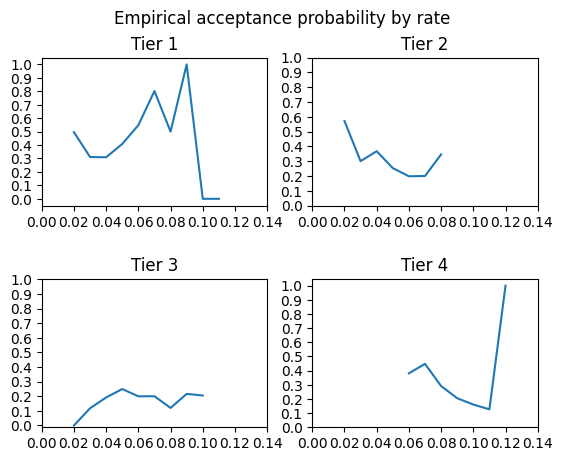

In [9]:
fig, axes = plt.subplots(2,2)
for i, ax in enumerate(axes.flatten()):
    df_ = df[df["Tier"]==(i+1)][["Rate", "Outcome"]]
    total_per_bucket, _ = np.histogram(df_["Rate"],[0.01*i for i in range(15)])
    accepted_per_bucket, _ = np.histogram(df_[df_["Outcome"]==1]["Rate"], [0.01*i for i in range(15)])
    ax.plot([0.01*i for i in range(14)], accepted_per_bucket/total_per_bucket)
    ax.set_xticks([0.02*i for i in range(8)])
    ax.set_yticks([0.1*i for i in range(11)])
    ax.set_title(f"Tier {i+1}")

plt.subplots_adjust(hspace=0.5)
plt.suptitle("Empirical acceptance probability by rate")


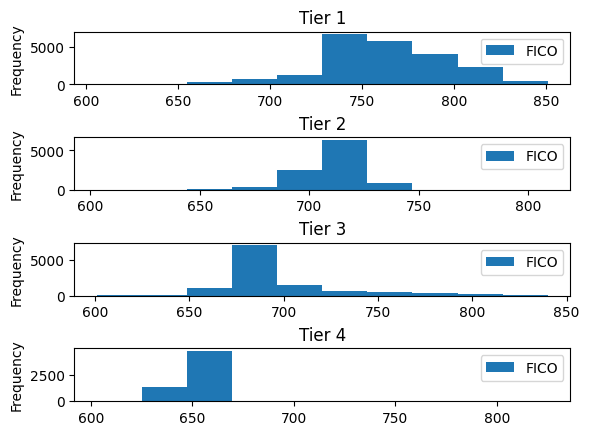

In [10]:
axes = df[["FICO", "Tier"]].plot.hist("Tier")
plt.title("FICO score distribution")
for i, ax in enumerate(axes): ax.set_title(f"Tier {i+1}")
plt.subplots_adjust(hspace=1)

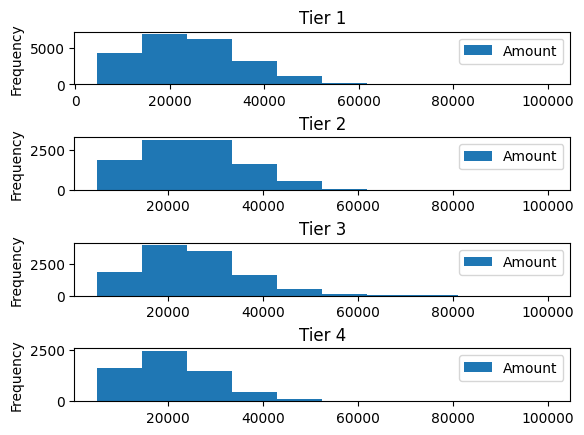

In [11]:
axes = df[["Amount", "Tier"]].plot.hist("Tier")
plt.title("Request Amount per Tier")
for i, ax in enumerate(axes): ax.set_title(f"Tier {i+1}")
plt.subplots_adjust(hspace=1)

Text(0.5, 0.98, 'Outcome vs requested Amount by Tier')

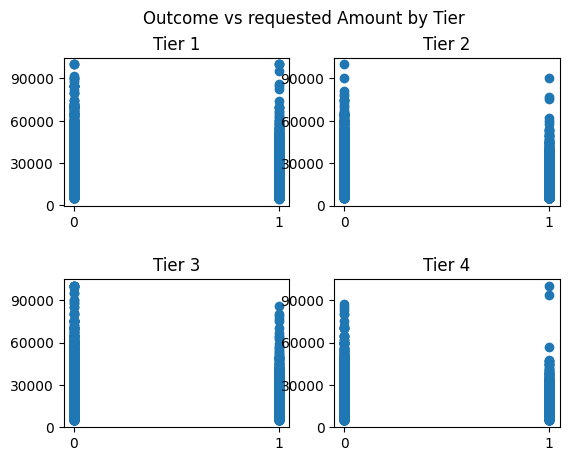

In [16]:
fig, axes = plt.subplots(2,2)
for i, ax in enumerate(axes.flatten()):
    df_ = df[df["Tier"] == 1+i]
    ax.scatter(df_["Outcome"],df_["Amount"])
    ax.set_xticks([0,1])
    ax.set_yticks([0, 30000, 60000, 90000])
    ax.set_title(f"Tier {i+1}")

plt.subplots_adjust(hspace=0.5)
plt.suptitle("Outcome vs requested Amount by Tier")

Comments:
1. Except for Tier 1 with around 20k data points, the other tiers are approximately equidistributed with 10k data points each
2. Independently on the tier, most loans are not being accepted
3. Looking at the Pearson correlation coefficient, there does not seem to be a strong correlation between offered rate and the acceptance of the loans. Tier 1 and 2 even show positive correlation
4. Tier 4 and 2 are the one showing the most intuitive acceptance pattern. Tier 2 in particular. However, at the tails of the offered rates the behaviour is less clearly interpretable (e.g. very few loans have very high rates, but out of those few the majority of the loans is being accepted). This suggests that either we have some outliers in the data or within the different tiers there are some riskier client
5. This behaviour is even more accentuated in Tier 3 and 4. There we can observe a wider range of offered rates and the loans are being accepted almost at every price points.
6. The classification in the various tiers seem to dependend quite strongly on the Fico score
7. The amount requested seems to be equally distributed in all the different tiers and not correlated with acceptance/rejections
8. In the book's chapter 4 the concepts of indipendent and latent price-dependent risk are introduced. These concepts could explain some of the values that we observe in the "tail" of the offered rates for each tier.